# Runtime execution data
These scripts calculate and plot execution time for each tool.

In [1]:
from helpers.sqlite_helpers import sql_query_to_pd
import pandas as pd

In [2]:
execution_time_per_scenario_query = f"""
    SELECT
      tool,
      scenario_id,
      time_in_ns / 1e6 as time_in_ms
    FROM
      global_executions_per_commit
  """

sql_query_to_pd(execution_time_per_scenario_query)

,tool,scenario_id,time_in_ms
0,DIFF3,Aloha-Editor:00a6c633d2b84d5ad690f402a5309e855...,55.399778
1,LAST_MERGE,Aloha-Editor:00a6c633d2b84d5ad690f402a5309e855...,20851.947380
2,MERGIRAF,Aloha-Editor:00a6c633d2b84d5ad690f402a5309e855...,2943.691713
3,DIFF3,Aloha-Editor:197932290361595d119def12ed4e4cfd2...,204.294033
4,LAST_MERGE,Aloha-Editor:197932290361595d119def12ed4e4cfd2...,2533.588451
...,...,...,...
4090,LAST_MERGE,wekan:d0dc206ffc15f74adc38f2b52312cf14479ba8ff,6195.451331
4091,MERGIRAF,wekan:d0dc206ffc15f74adc38f2b52312cf14479ba8ff,190.815878
4092,DIFF3,workbox:d02020b3eb2a63bc6ed80c132d235a57f01287c0,6.524007
4093,LAST_MERGE,workbox:d02020b3eb2a63bc6ed80c132d235a57f01287c0,116.226144


## Plotting execution time per scenario

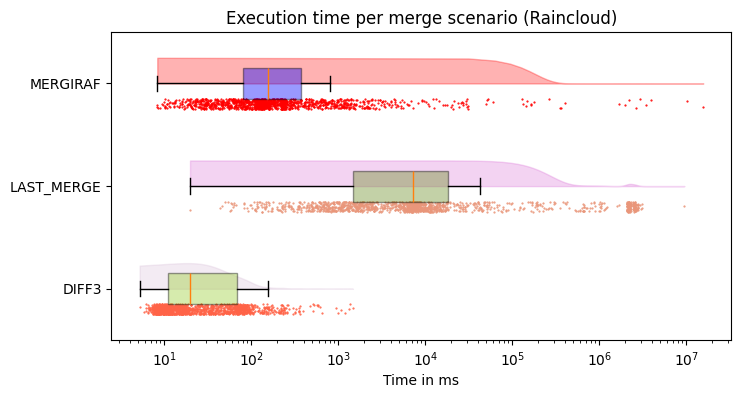

In [3]:
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

execution_times_raw = sql_query_to_pd(execution_time_per_scenario_query)
execution_times_raw

tools = execution_times_raw['tool'].unique()

execution_times = execution_times_raw.pivot(
    index="scenario_id",
    columns="tool",
    values="time_in_ms"
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 4))

# Create a list of colors for the boxplots based on the number of features you have
boxplots_colors = ['yellowgreen', 'olivedrab', 'blue', 'red']

# Boxplot data
bp = ax.boxplot(execution_times, patch_artist = True, vert = False, showfliers = False)

# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], boxplots_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.4)

# Create a list of colors for the violin plots based on the number of features you have
violin_colors = ['thistle', 'orchid', 'red', 'blue']

# Violinplot data
vp = ax.violinplot(execution_times, points=500,
               showmeans=False, showextrema=False, showmedians=False, vert=False)

for idx, b in enumerate(vp['bodies']):
    # Get the center of the plot
    m = np.mean(b.get_paths()[0].vertices[:, 0])
    # Modify it so we only see the upper half of the violin plot
    b.get_paths()[0].vertices[:, 1] = np.clip(b.get_paths()[0].vertices[:, 1], idx+1, idx+2)
    # Change to the desired color
    b.set_color(violin_colors[idx])

# Create a list of colors for the scatter plots based on the number of features you have
scatter_colors = ['tomato', 'darksalmon', 'red', 'tomato']

# Scatterplot data
for idx, features in enumerate(execution_times):
    features = execution_times[features]
    # Add jitter effect so the features do not overlap on the y-axis
    y = np.full(len(features), idx + .8)
    idxs = np.arange(len(y))
    out = y.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.05, high=.05, size=len(idxs))
    y = out
    plt.scatter(features, y, s=.3, c=scatter_colors[idx])

plt.yticks(np.arange(1,len(tools) + 1,1), tools)  # Set text labels.
plt.xlabel('Time in ms')
plt.title("Execution time per merge scenario (Raincloud)")
ax.set_xscale('log')
plt.show()

In [4]:
execution_times = sql_query_to_pd(execution_time_per_scenario_query)
stats = pd.DataFrame(data = [
  {
      "tool": tool,
      "average": execution_times.loc[execution_times["tool"] == tool, "time_in_ms"].mean(),
      "std_avg": execution_times.loc[execution_times["tool"] == tool, "time_in_ms"].std(),
      "median": execution_times.loc[execution_times["tool"] == tool, "time_in_ms"].median(),
      "max": execution_times.loc[execution_times["tool"] == tool, "time_in_ms"].max(),
      "min": execution_times.loc[execution_times["tool"] == tool, "time_in_ms"].min()
  } for tool in tools
])

stats

,tool,average,std_avg,median,max,min
0,DIFF3,54.456324,107.809253,19.618152,1.473719e+03,5.224315
1,LAST_MERGE,321288.351133,802711.134013,7185.161300,9.502399e+06,19.809143
2,MERGIRAF,35477.512549,542737.418815,154.507890,1.567641e+07,8.327802


In [5]:
top_highest_execution_times_last_merge_query = f"""
    SELECT
        *
    FROM
        global_executions
    WHERE
        tool = "LAST_MERGE"
        and time_in_ns < 6e+10
    ORDER BY
        time_in_ns DESC
"""
sql_query_to_pd(top_highest_execution_times_last_merge_query)

,project,merge_sha,file_path,output_file_path,result,time_in_ns,scenario_id,language,tool
0,cryptpad,e06700a88f96b992d0c3f25329bc36adf877c54c,output/cryptpad/e06700a88f96b992d0c3f25329bc36...,output/cryptpad/e06700a88f96b992d0c3f25329bc36...,SUCCESS_WITH_CONFLICTS,59104926714,cryptpad:e06700a88f96b992d0c3f25329bc36adf877c54c,JAVASCRIPT,LAST_MERGE
1,two.js,18e00471b521ffe3a42faaf92680d39387d789ad,output/two.js/18e00471b521ffe3a42faaf92680d393...,output/two.js/18e00471b521ffe3a42faaf92680d393...,SUCCESS_WITH_CONFLICTS,58313488853,two.js:18e00471b521ffe3a42faaf92680d39387d789ad,JAVASCRIPT,LAST_MERGE
2,two.js,45dd66ec468d17834a67a9123afc862a6e3d32c3,output/two.js/45dd66ec468d17834a67a9123afc862a...,output/two.js/45dd66ec468d17834a67a9123afc862a...,SUCCESS_WITH_CONFLICTS,58012701167,two.js:45dd66ec468d17834a67a9123afc862a6e3d32c3,JAVASCRIPT,LAST_MERGE
3,qs,9d441d270486c3cc77f17289a9e0921c0f742aff,output/qs/9d441d270486c3cc77f17289a9e0921c0f74...,output/qs/9d441d270486c3cc77f17289a9e0921c0f74...,SUCCESS_WITHOUT_CONFLICTS,57560449260,qs:9d441d270486c3cc77f17289a9e0921c0f742aff,JAVASCRIPT,LAST_MERGE
4,cryptpad,bbc112ec3c10d9ec100b8fd39430b50911c5d506,output/cryptpad/bbc112ec3c10d9ec100b8fd39430b5...,output/cryptpad/bbc112ec3c10d9ec100b8fd39430b5...,SUCCESS_WITH_CONFLICTS,56239298224,cryptpad:bbc112ec3c10d9ec100b8fd39430b50911c5d506,JAVASCRIPT,LAST_MERGE
...,...,...,...,...,...,...,...,...,...
2169,metroui,b81eaa823082a3479dcc9a2770238b90b2a2f97f,output/metroui/b81eaa823082a3479dcc9a2770238b9...,output/metroui/b81eaa823082a3479dcc9a2770238b9...,SUCCESS_WITHOUT_CONFLICTS,22209030,metroui:b81eaa823082a3479dcc9a2770238b90b2a2f97f,JAVASCRIPT,LAST_MERGE
2170,mongoose,20bb91ca404cf64266d0ec58e83fb40a9087b774,output/mongoose/20bb91ca404cf64266d0ec58e83fb4...,output/mongoose/20bb91ca404cf64266d0ec58e83fb4...,SUCCESS_WITH_CONFLICTS,21720263,mongoose:20bb91ca404cf64266d0ec58e83fb40a9087b774,JAVASCRIPT,LAST_MERGE
2171,mongoose,20bb91ca404cf64266d0ec58e83fb40a9087b774,output/mongoose/20bb91ca404cf64266d0ec58e83fb4...,output/mongoose/20bb91ca404cf64266d0ec58e83fb4...,SUCCESS_WITH_CONFLICTS,21450812,mongoose:20bb91ca404cf64266d0ec58e83fb40a9087b774,JAVASCRIPT,LAST_MERGE
2172,mpx,df3430758e81f55a95a244266173303a86f41cde,output/mpx/df3430758e81f55a95a244266173303a86f...,output/mpx/df3430758e81f55a95a244266173303a86f...,SUCCESS_WITHOUT_CONFLICTS,20247556,mpx:df3430758e81f55a95a244266173303a86f41cde,JAVASCRIPT,LAST_MERGE
